# 🇧🇷 Brazilian Health Data with PySUS

This notebook demonstrates how to access Brazilian public health data using the PySUS library.

**Data Sources:**
- **SINAN** - Notifiable Diseases (dengue, malaria, COVID-19, etc.)
- **SIM** - Mortality Information System
- **SIH** - Hospital Information System
- **SIA** - Outpatient Information System
- **CNES** - National Health Establishments Registry

**Requirements:**
```bash
pip install pysus pandas matplotlib seaborn plotly
```

## 1. Setup and Imports

In [38]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# PySUS imports
from pysus import SIH, SIM, SINAN
from pysus.preprocessing.decoders import decodifica_idade_SINAN

# from pysus.preprocessing.decoders import translate_variables

print("✅ Imports completed successfully!")
print(f"⏰ Current time: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

✅ Imports completed successfully!
⏰ Current time: 2026-03-14 10:48


## 2. Exploring Available Data

In [31]:
# List available diseases in SINAN
print("📋 Available diseases in SINAN:")
sinan = SINAN().load()
i=1
for abbrv,disname in sinan.diseases.items():
    print(f"  {i:2d}. {abbrv} - {disname}")
    i += 1


📋 Available diseases in SINAN:
   1. ACBI - Acidente de trabalho com material biológico
   2. ACGR - Acidente de trabalho
   3. ANIM - Acidente por Animais Peçonhentos
   4. ANTR - Atendimento Antirrabico
   5. BOTU - Botulismo
   6. CANC - Cancêr relacionado ao trabalho
   7. CHAG - Doença de Chagas Aguda
   8. CHIK - Febre de Chikungunya
   9. COLE - Cólera
  10. COQU - Coqueluche
  11. DENG - Dengue
  12. DERM - Dermatoses ocupacionais
  13. DIFT - Difteria
  14. ESQU - Esquistossomose
  15. EXAN - Doença exantemáticas
  16. FMAC - Febre Maculosa
  17. FTIF - Febre Tifóide
  18. HANS - Hanseníase
  19. HANT - Hantavirose
  20. HEPA - Hepatites Virais
  21. IEXO - Intoxicação Exógena
  22. INFL - Influenza Pandêmica
  23. LEIV - Leishmaniose Visceral
  24. LEPT - Leptospirose
  25. LERD - LER/Dort
  26. LTAN - Leishmaniose Tegumentar Americana
  27. MALA - Malária
  28. MENI - Meningite
  29. MENT - Transtornos mentais relacionados ao trabalho
  30. NTRA - Notificação de Tracoma
  31

## 3. Dengue Data Analysis

In [46]:
# Download dengue data for Rio de Janeiro (2022-2023)
files = sinan.get_files(dis_code=["DENG",], year=[2022, 2023])
print("📥 Downloading dengue data for Rio de Janeiro...")

try:
    # Get dengue notifications for RJ in 2023
    dengue_rj_2022 = sinan.download(files[0]).to_dataframe()
    dengue_rj_2023 = sinan.download(files[1]).to_dataframe()

    print(f"✅ Downloaded {len(dengue_rj_2023)} records")
    print(f"\n📊 DataFrame shape: {dengue_rj_2023.shape}")
    print(f"\n📝 Columns: {list(dengue_rj_2023.columns)[:10]}...")

    # Display first few rows
    dengue_rj_2023.head()

except Exception as e:
    print(f"⚠️ Error downloading data: {e}")
    print("\n💡 Tip: Make sure you have internet connection and PySUS is properly installed")

📥 Downloading dengue data for Rio de Janeiro...


62196735it [00:00, 83908656930.67it/s]
61357579it [00:00, 89638571588.30it/s]


✅ Downloaded 1372151 records

📊 DataFrame shape: (1372151, 121)

📝 Columns: ['TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'SEM_NOT', 'NU_ANO', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'DT_SIN_PRI']...


In [54]:
# Data exploration
dengue_rj_2023 = dengue_rj_2023.convert_dtypes()
if 'dengue_rj_2023' in locals() and len(dengue_rj_2023) > 0:
    print("🔍 Data Exploration:\n")

    # Basic statistics
    print("📈 Basic Statistics:")
    print(f"  Total cases: {len(dengue_rj_2023):,}")

    # Age distribution
    if 'NU_IDADE_N' in dengue_rj_2023.columns:
        rj_2023=dengue_rj_2023.dropna(subset=['NU_IDADE_N'])
        rj_2023['NU_IDADE_N'] = decodifica_idade_SINAN(dengue_rj_2023.NU_IDADE_N, 'Y')

        rj_2023.NU_IDADE_N = np.floor(rj_2023.NU_IDADE_N).astype("Int64")
        rj_2023=rj_2023[rj_2023.NU_IDADE_N<150]
        print(f"\n  Age range: {rj_2023['NU_IDADE_N'].min()} - {rj_2023['NU_IDADE_N'].max()} years")
        print(f"  Mean age: {rj_2023['NU_IDADE_N'].mean()} years")

    # Gender distribution
    if 'CS_SEXO' in dengue_rj_2023.columns:
        gender_counts = dengue_rj_2023['CS_SEXO'].value_counts()
        print("\n  Gender distribution:")
        for gender, count in gender_counts.items():
            percentage = (count / len(dengue_rj_2023)) * 100
            print(f"    {gender}: {count:,} ({percentage:.1f}%)")

    # Evolution status
    if 'EVOLUCAO' in dengue_rj_2023.columns:
        print("\n  Evolution status:")
        evol_counts = dengue_rj_2023['EVOLUCAO'].value_counts()
        for status, count in evol_counts.head(5).items():
            print(f"    {status}: {count:,}")

🔍 Data Exploration:

📈 Basic Statistics:
  Total cases: 1,372,151

  Age range: 0 - 123 years
  Mean age: 34.685051295431954 years

  Gender distribution:
    F: 738,193 (53.8%)
    M: 631,801 (46.0%)
    I: 2,152 (0.2%)
    : 5 (0.0%)

  Evolution status:
    1: 916,611
    : 425,764
    9: 28,505
    2: 774
    4: 297


## 4. Visualizations

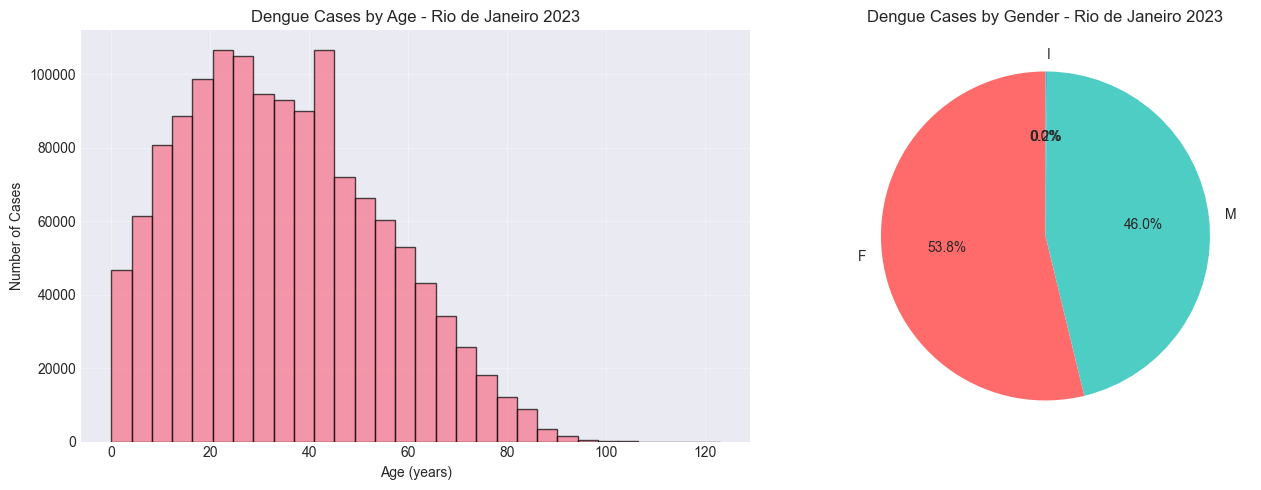

In [56]:
# Age distribution histogram
if 'dengue_rj_2023' in locals() and 'NU_IDADE_N' in dengue_rj_2023.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Age histogram
    axes[0].hist(rj_2023['NU_IDADE_N'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Age (years)')
    axes[0].set_ylabel('Number of Cases')
    axes[0].set_title('Dengue Cases by Age - Rio de Janeiro 2023')
    axes[0].grid(True, alpha=0.3)

    # Gender distribution
    if 'CS_SEXO' in dengue_rj_2023.columns:
        gender_data = dengue_rj_2023['CS_SEXO'].value_counts()
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
        axes[1].pie(gender_data.values, labels=gender_data.index, autopct='%1.1f%%',
                   colors=colors, startangle=90)
        axes[1].set_title('Dengue Cases by Gender - Rio de Janeiro 2023')

    plt.tight_layout()
    plt.show()

In [9]:
# Time series analysis (if date column available)
if 'dengue_rj_2023' in locals() and 'DT_NOTIFIC' in dengue_rj_2023.columns:
    # Convert date column
    dengue_rj_2023['DT_NOTIFIC'] = pd.to_datetime(dengue_rj_2023['DT_NOTIFIC'], errors='coerce')

    # Group by month
    monthly_cases = dengue_rj_2023.groupby(dengue_rj_2023['DT_NOTIFIC'].dt.to_period('M')).size()

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    monthly_cases.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Cases')
    ax.set_title('Dengue Cases by Month - Rio de Janeiro 2023')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Peak month: {monthly_cases.idxmax()} with {monthly_cases.max()} cases")

## 5. Mortality Data (SIM)

In [63]:
# Download mortality data for São Paulo
print("📥 Downloading mortality data for São Paulo (2022)...")
sim = SIM().load()
files = sim.get_files(year=2022, uf=['SP',], group=['CID10',])
try:
    # Get mortality data for SP in 2022
    sim_sp_2022 = sim.download(files).to_dataframe()

    print(f"✅ Downloaded {len(sim_sp_2022):,} death records")

    # Top causes of death
    if 'CAUSABAS' in sim_sp_2022.columns:
        print("\n💀 Top 10 Causes of Death (ICD-10 codes):")
        top_causes = sim_sp_2022['CAUSABAS'].value_counts().head(10)
        for i, (cause, count) in enumerate(top_causes.items(), 1):
            print(f"  {i:2d}. {cause}: {count:,} cases")

except Exception as e:
    print(f"⚠️ Error downloading SIM data: {e}")

📥 Downloading mortality data for São Paulo (2022)...


28630082it [00:00, 83449108723.37it/s]


✅ Downloaded 354,056 death records

💀 Top 10 Causes of Death (ICD-10 codes):
   1. I219: 25,916 cases
   2. B342: 18,475 cases
   3. J189: 10,606 cases
   4. N390: 8,566 cases
   5. R99 : 7,469 cases
   6. G309: 7,458 cases
   7. C349: 6,881 cases
   8. J180: 6,719 cases
   9. I64 : 6,350 cases
  10. E149: 6,309 cases


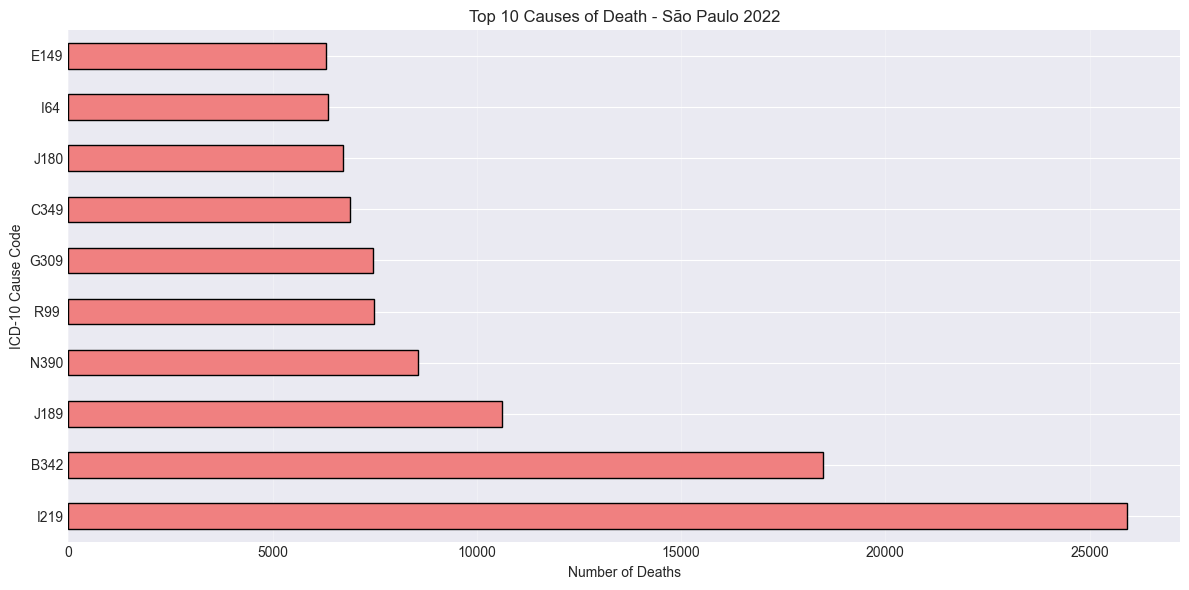

In [64]:
# Visualize top causes of death
if 'sim_sp_2022' in locals() and 'CAUSABAS' in sim_sp_2022.columns:
    top_10_causes = sim_sp_2022['CAUSABAS'].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(12, 6))
    top_10_causes.plot(kind='barh', ax=ax, color='lightcoral', edgecolor='black')
    ax.set_xlabel('Number of Deaths')
    ax.set_ylabel('ICD-10 Cause Code')
    ax.set_title('Top 10 Causes of Death - São Paulo 2022')
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

## 6. Hospitalizations (SIH)

In [71]:
# Download hospitalization data
print("📥 Downloading hospitalization data for Minas Gerais (2023)...")
sih = SIH().load()
files = sih.get_files(year=2023, uf="MG", group="RD", month=1)
try:
    # Get hospitalization data for MG in 2023
    sih_mg_2023 = sih.download(files).to_dataframe().convert_dtypes()


    print(f"✅ Downloaded {len(sih_mg_2023):,} hospitalization records")

    if 'VAL_TOT' in sih_mg_2023.columns:
        sih_mg_2023.VAL_TOT = sih_mg_2023.VAL_TOT.astype("Float64")
        total_cost = sih_mg_2023['VAL_TOT'].sum()
        mean_cost = sih_mg_2023['VAL_TOT'].mean()
        print("\n💰 Hospitalization Costs:")
        print(f"  Total: R$ {total_cost:,.2f}")
        print(f"  Average per hospitalization: R$ {mean_cost:,.2f}")

except Exception as e:
    print(f"⚠️ Error downloading SIH data: {e}")

📥 Downloading hospitalization data for Minas Gerais (2023)...


8737930it [00:00, 30339018833.38it/s]


✅ Downloaded 111,575 hospitalization records

💰 Hospitalization Costs:
  Total: R$ 194,617,739.94
  Average per hospitalization: R$ 1,744.28


## 7. Comparative Analysis: Multiple States

In [74]:
# Compare dengue across multiple states
states = ["RJ", "SP", "MG", "BA"]
state_names = {"RJ": "Rio de Janeiro", "SP": "São Paulo",
               "MG": "Minas Gerais", "BA": "Bahia"}

state_data = {}

print("📥 Downloading dengue data for multiple states...")
for state in states:
    files = sinan.get_files(year=2023, dis_code="DENG")
    try:
        df = sinan.download(files).to_dataframe()
        df = df[df['UF'] == state]
        state_data[state] = len(df)
        print(f"  {state_names[state]} ({state}): {len(df):,} cases")
    except Exception as e:
        print(f"  ⚠️ {state}: {e}")
        state_data[state] = 0

📥 Downloading dengue data for multiple states...


61357579it [00:00, 90425979982.44it/s]


  Rio de Janeiro (RJ): 0 cases


61357579it [00:00, 95527965489.98it/s]


  São Paulo (SP): 0 cases


61357579it [00:00, 94441225332.12it/s]


  Minas Gerais (MG): 0 cases


61357579it [00:00, 95174681593.94it/s]


  Bahia (BA): 0 cases


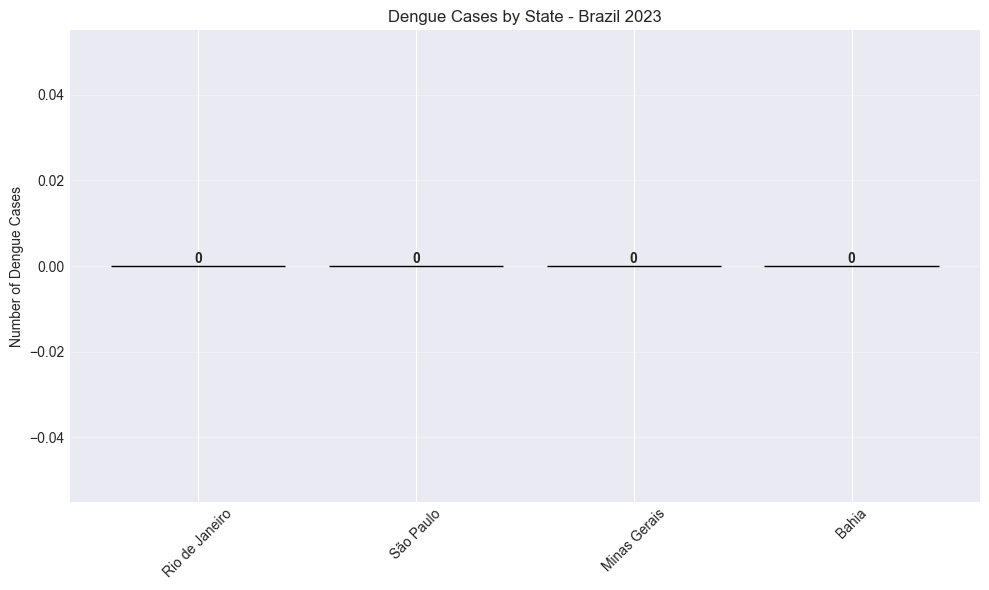


📊 Summary:
  Total cases: 0
  Highest: ('RJ', 0)
  Lowest: ('RJ', 0)


In [75]:
# Visualize comparison
if state_data:
    fig, ax = plt.subplots(figsize=(10, 6))

    states_list = list(state_data.keys())
    cases_list = list(state_data.values())
    names = [state_names[s] for s in states_list]

    bars = ax.bar(names, cases_list, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'],
                  edgecolor='black')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_ylabel('Number of Dengue Cases')
    ax.set_title('Dengue Cases by State - Brazil 2023')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Summary statistics
    total_cases = sum(cases_list)
    print("\n📊 Summary:")
    print(f"  Total cases: {total_cases:,}")
    print(f"  Highest: {max(state_data.items(), key=lambda x: x[1])}")
    print(f"  Lowest: {min(state_data.items(), key=lambda x: x[1])}")

## 8. Export Data

In [76]:
# Save processed data
output_dir = "./output"
import os

os.makedirs(output_dir, exist_ok=True)

if 'dengue_rj_2023' in locals():
    output_file = os.path.join(output_dir, "dengue_rj_2023.csv")
    dengue_rj_2023.to_csv(output_file, index=False)
    print(f"✅ Saved dengue data to: {output_file}")
    print(f"   File size: {os.path.getsize(output_file) / 1024:.1f} KB")

if 'sim_sp_2022' in locals():
    output_file = os.path.join(output_dir, "sim_sp_2022.csv")
    sim_sp_2022.to_csv(output_file, index=False)
    print(f"✅ Saved mortality data to: {output_file}")
    print(f"   File size: {os.path.getsize(output_file) / 1024:.1f} KB")

print(f"\n📁 All outputs saved to: {os.path.abspath(output_dir)}/")

✅ Saved dengue data to: ./output/dengue_rj_2023.csv
   File size: 367622.7 KB
✅ Saved mortality data to: ./output/sim_sp_2022.csv
   File size: 123851.1 KB

📁 All outputs saved to: /home/fccoelho/Documentos/Projects_Software/epidemiological-datasets/examples/notebooks/output/


## 9. Summary and Next Steps

### What We Learned:

1. **PySUS provides easy access** to Brazilian health data from DATASUS
2. **Multiple databases available**: SINAN (diseases), SIM (mortality), SIH (hospitalizations)
3. **Data includes**: demographics, dates, locations, diagnoses, and outcomes
4. **Analysis possibilities**: Time series, geographic comparisons, risk factors

### Next Steps:

- 🔍 **Explore other diseases**: Chikungunya, Zika, Malaria, COVID-19
- 🗺️ **Geospatial analysis**: Map cases by municipality
- 📈 **Time series forecasting**: Predict future outbreaks
- 🔗 **Merge datasets**: Link SINAN with SIM for outcome analysis

### Resources:

- PySUS Documentation: https://pysus.readthedocs.io/
- DATASUS: https://datasus.saude.gov.br/
- SINAN Manual: https://portalsinan.saude.gov.br/

---

**Notebook created:** 2024
**Author:** Epidemiological Datasets Repository